In [50]:
# First run this cell to  import required libraries
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import weibull_min
from scipy.special import gamma

import matplotlib.dates as mdates

import glob, os

In [64]:
# Observations

DATA_DIR = "/home/frmol0570/PhD/CODING_UNIS/data"

# station name as in the file name & start of field deployment
STATIONS = {
    "Bobby Mcgee": "2026-10-06 10:40",
    "MrsRobinson": "2026-10-06 12:08",
    "Rosanne": "2026-10-07 09:35",
}

STATION = "MrsRobinson"  # choose: "Bobby Mcgee", "MrsRobinson", "Rosanne"

files = sorted(glob.glob(os.path.join(DATA_DIR, f"{STATION}_*Res_data_1_min_*.dat")))
if not files:
    raise FileNotFoundError(
        f"No 1-min file found for station '{STATION}' in {DATA_DIR}"
    )
file = files[-1]  # newest download if there are several
START = STATIONS[STATION]
print("Using:", os.path.basename(file), "| start:", START)

with open(file, "r", errors="ignore") as f:
    for i in range(20):
        print(f.readline().rstrip())


Using: MrsRobinson_CR200 Series_Res_data_1_min_2026-10-07T11-59.dat | start: 2026-10-06 12:08
"TOA5","CR200 Series","CR2xx","","v10","mini_AWS_MrsRo.","17222","Res_data_1_min"
"TIMESTAMP","RECORD","BattV","temperature","rel_humidity","wind_speed","gust_speed","wind_direction"
"TS","RN","Volts","degC","%","m/s","m/s","deg"
"","","Min","Avg","Smp","Avg","Max","Smp"
"2026-10-05 14:00:00",0,12.45224,9.19722,65.92342,0,0,89.62997
"2026-10-05 14:01:00",1,12.443,29.11711,68.87215,0,0,87.90482
"2026-10-05 14:02:00",2,12.443,29.38662,68.34559,0,0,87.08992
"2026-10-05 14:03:00",3,12.43377,30.71357,68.11971,0,0,86.16233
"2026-10-05 14:04:00",4,12.44216,33.95075,60.81811,0,0,77.85081
"2026-10-05 14:10:00",5,12.43545,22.77247,27.61906,0,0,22.18643
"2026-10-05 14:14:00",6,12.43964,22.64488,40.7021,0.17444,0.588,170.9203
"2026-10-05 16:32:00",7,13.14729,30.852,69.30407,0,0,88.05002
"2026-10-06 12:08:00",8,12.03336,0.4774034,89.94969,0.06097778,0.0784,303.4537
"2026-10-06 12:09:00",9,12.02664,0.501144

In [65]:
# DATA PREP "NAN" strings -> NaN so columns become numeric ---
df = pd.read_csv(
    file,
    skiprows=[0, 2, 3],  # skip metadata, units, and process-type rows
    parse_dates=["TIMESTAMP"],
    index_col="TIMESTAMP",
    na_values=["NAN"],
)

In [66]:
# --- Keep only the field deployment (earlier records are indoor/lab tests and set-up) ---
# Check this against your field notes!
obs = df.loc[START:].copy()

In [67]:
# --- Put on a regular 1-min time axis so missing minutes show up as gaps (NaN), not interpolated lines ---
obs = obs.asfreq("1min")

In [68]:
# --- Wind direction is undefined in calm conditions: mask it below a threshold ---
CALM = 0.5  # m/s (WMO definition of calm)
obs.loc[obs["wind_speed"] < CALM, "wind_direction"] = np.nan

In [69]:
# --- 10-min averages ---
# speed: scalar mean; direction: VECTOR mean (an arithmetic mean of 350° and 10° would give 180°!)
u = -obs["wind_speed"] * np.sin(np.deg2rad(obs["wind_direction"]))
v = -obs["wind_speed"] * np.cos(np.deg2rad(obs["wind_direction"]))
avg = pd.DataFrame(
    {
        "temperature": obs["temperature"].resample("10min").mean(),
        "wind_speed": obs["wind_speed"].resample("10min").mean(),
        "gust_speed": obs["gust_speed"].resample("10min").max(),
        "u": u.resample("10min").mean(),
        "v": v.resample("10min").mean(),
    }
)
avg["wind_direction"] = (np.rad2deg(np.arctan2(-avg["u"], -avg["v"])) + 360) % 360
avg.loc[avg["wind_speed"] < CALM, "wind_direction"] = np.nan
avg.index = avg.index + pd.Timedelta(
    "5min"
)  # plot each average at the centre of its interval


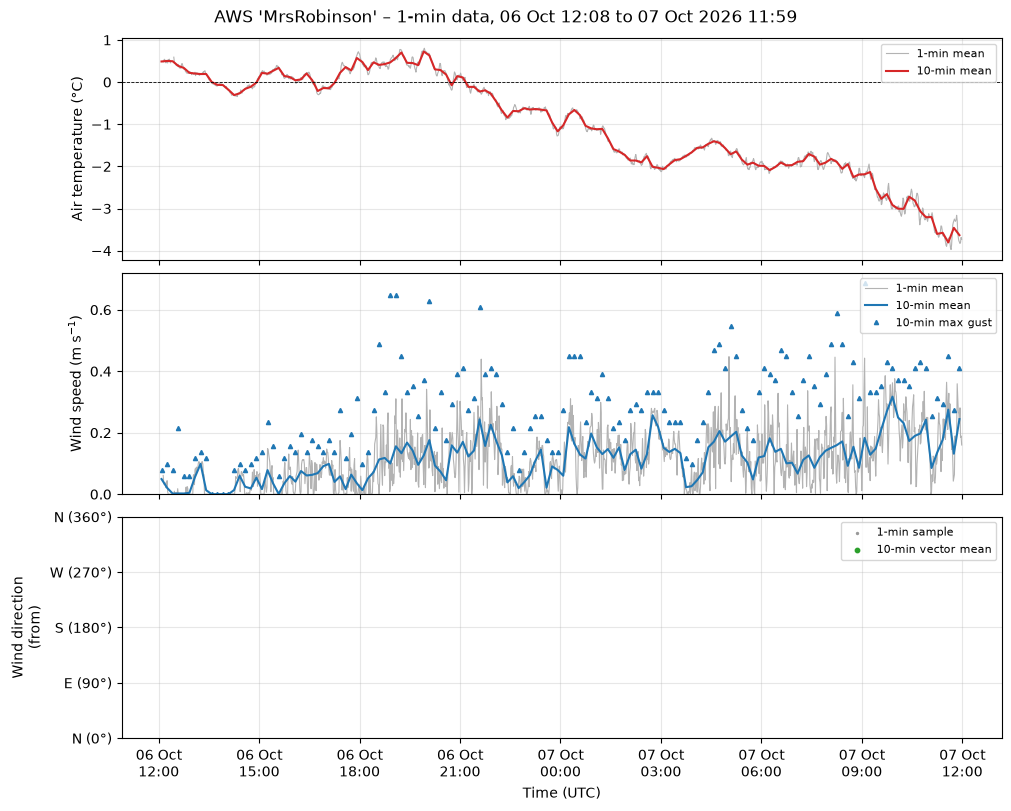

In [70]:
# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

# Temperature
ax = axes[0]
ax.plot(obs.index, obs["temperature"], color="0.7", lw=0.8, label="1-min mean")
ax.plot(avg.index, avg["temperature"], color="tab:red", lw=1.5, label="10-min mean")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_ylabel("Air temperature (°C)")
ax.legend(loc="upper right", fontsize=8)

# Wind speed
ax = axes[1]
ax.plot(obs.index, obs["wind_speed"], color="0.7", lw=0.8, label="1-min mean")
ax.plot(avg.index, avg["wind_speed"], color="tab:blue", lw=1.5, label="10-min mean")
ax.plot(
    avg.index,
    avg["gust_speed"],
    color="tab:blue",
    lw=0,
    marker="^",
    ms=3,
    label="10-min max gust",
)
ax.set_ylabel("Wind speed (m s$^{-1}$)")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=8)

# Wind direction: points, not lines (a line would jump across the plot at 360°/0°)
ax = axes[2]
ax.scatter(obs.index, obs["wind_direction"], s=2, color="0.6", label="1-min sample")
ax.scatter(
    avg.index,
    avg["wind_direction"],
    s=10,
    color="tab:green",
    label="10-min vector mean",
)
ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_yticklabels(["N (0°)", "E (90°)", "S (180°)", "W (270°)", "N (360°)"])
ax.set_ylabel("Wind direction\n(from)")
ax.legend(loc="upper right", fontsize=8)

# Shared time axis
axes[-1].xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3)))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
axes[-1].set_xlabel("Time (UTC)")  # check the logger clock setting!
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(
    f"AWS '{STATION}' – 1-min data, "
    f"{obs.index[0]:%d %b %H:%M} to {obs.index[-1]:%d %b %Y %H:%M}"
)

plt.show()

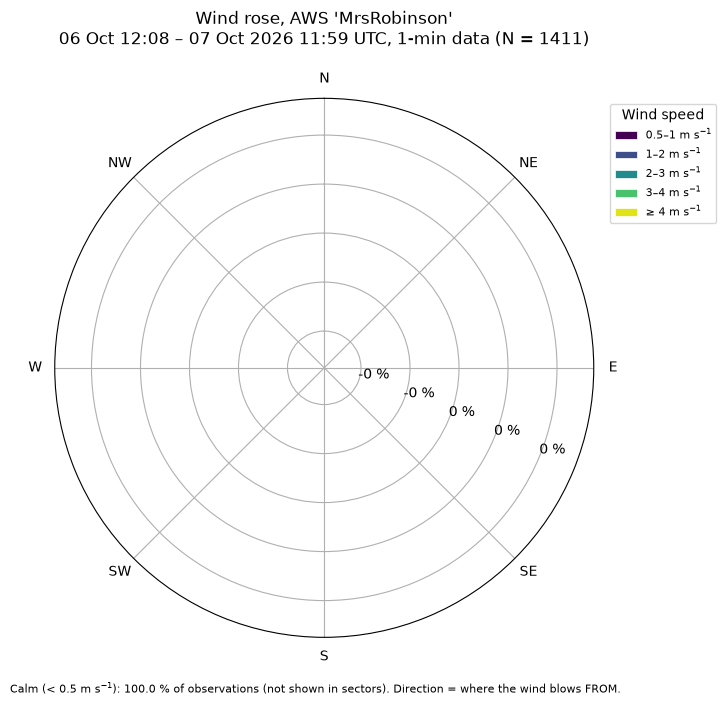

In [71]:
# --- Wind rose from the 1-min data (uses df, obs, START, CALM from the cell above) ---
ws = obs["wind_speed"]
wd = df.loc[START:, "wind_direction"].reindex(obs.index)  # unmasked direction

valid = ws.notna() & wd.notna()
ws, wd = ws[valid], wd[valid]
n_total = len(ws)

# Calms have no defined direction -> count them separately, don't put them in a sector
calm = ws < CALM
calm_pct = 100 * calm.sum() / n_total
ws, wd = ws[~calm], wd[~calm]

# 16 sectors of 22.5°, CENTRED on N, NNE, ... (N sector = 348.75°–11.25°)
n_sec = 16
width = 360 / n_sec
sector = np.floor(((wd + width / 2) % 360) / width).astype(int)
centres = np.deg2rad(np.arange(n_sec) * width)

# Speed classes (m/s)
speed_bins = [CALM, 1, 2, 3, 4, np.inf]
labels = [
    f"{a:g}–{b:g}" if np.isfinite(b) else f"≥ {a:g}"
    for a, b in zip(speed_bins[:-1], speed_bins[1:])
]
speed_cls = pd.cut(ws, speed_bins, right=False, labels=labels)

# Frequency in % of ALL valid obs (sectors + calm add up to 100 %)
table = pd.crosstab(sector, speed_cls).reindex(
    index=range(n_sec), columns=labels, fill_value=0
)
freq = 100 * table / n_total

# --- Plot ---
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N")  # North at the top
ax.set_theta_direction(-1)  # clockwise, like a compass

colors = plt.cm.viridis(np.linspace(0, 0.95, len(labels)))
bottom = np.zeros(n_sec)
for lab, c in zip(labels, colors):
    ax.bar(
        centres,
        freq[lab].values,
        width=np.deg2rad(width) * 0.95,
        bottom=bottom,
        color=c,
        edgecolor="white",
        lw=0.5,
        label=f"{lab} m s$^{{-1}}$",
    )
    bottom += freq[lab].values

ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_rlabel_position(112.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda r, _: f"{r:.0f} %"))

ax.legend(title="Wind speed", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_title(
    f"Wind rose, AWS '{STATION}'\n"
    f"{obs.index[0]:%d %b %H:%M} – {obs.index[-1]:%d %b %Y %H:%M} UTC, "
    f"1-min data (N = {n_total})",
    pad=20,
)

fig.text(
    0.5,
    0.03,
    f"Calm (< {CALM} m s$^{{-1}}$): {calm_pct:.1f} % of observations "
    "(not shown in sectors). Direction = where the wind blows FROM.",
    ha="center",
    fontsize=8,
)
plt.show()
